# Would instructional faculty recommend their department?

In [16]:
import pandas as pd
import numpy as np
import scipy 


non_response_codes = [96, 97, 98, 99]


instructional_data = pd.read_csv('/Users/henrysalgado/Desktop/Coache Data Analysis/october24_forest_imputed_data.csv')
instructional_data.replace(non_response_codes, np.nan, inplace=True)
instructional_data.describe()


,demo_inst_id,hacu_hsi,demo_tenure,demo_rank,demo_race,demo_gender,demo_is_clinical,demo_is_parent_any,demo_is_parent_itp,demo_is_parent_k12,...,q270b_19,q270b_20,q270b_21,q270b_22,q270b_23,q270b_24,q270b_25,q270b_98,q305,instructional
count,971.000000,971.0,971.000000,971.000000,968.000000,971.000000,920.0,970.000000,970.000000,970.000000,...,971.0,971.0,971.0,971.0,971.0,971.0,971.0,971.0,467.000000,971.0
mean,295.385170,1.0,1.781668,2.324408,3.733471,1.911432,0.0,0.482474,0.148454,0.284536,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.438972,1.0
std,61.934851,0.0,0.880320,1.680946,11.036708,5.754638,0.0,0.499951,0.355732,0.451426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.496794,0.0
min,126.000000,1.0,1.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
25%,303.000000,1.0,1.000000,1.000000,2.000000,1.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
50%,315.000000,1.0,1.000000,2.000000,2.000000,2.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
75%,319.000000,1.0,3.000000,3.000000,2.000000,2.000000,0.0,1.000000,0.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0
max,404.000000,1.0,3.000000,9.000000,91.000000,91.000000,0.0,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Majority of faculty would recommend their department (2), some with resevation (1) and 75 would not

In [18]:
instructional_data['q265'].value_counts()

2.0    515
1.0    381
0.0     75
Name: q265, dtype: int64

Features with less than 5% missing data: ['q45a', 'q45b', 'q45c', 'q45e', 'q60a', 'q60c', 'q60d', 'q60e', 'q70a', 'q70b', 'q70c', 'q70d', 'q70e', 'q70f', 'q70h', 'q90a', 'q90c', 'q90d', 'q90e', 'q90f', 'q90g', 'q90h', 'q95a', 'q95c', 'q105a', 'q105e', 'q105d', 'q140a', 'q140b', 'q450e', 'q460a', 'q460b', 'q185h', 'q185i', 'q185j', 'q185k', 'q185l', 'q195a', 'q195b', 'q195e', 'q200a', 'q205a', 'q205c', 'q205d', 'q210c', 'q212a', 'q215a', 'q215b', 'q215c', 'q215d', 'q215l', 'q215i', 'demo_rank', 'demo_race', 'demo_gender', 'demo_inst_carnegie_class']
Best Accuracy: 0.78 achieved with 48 features.


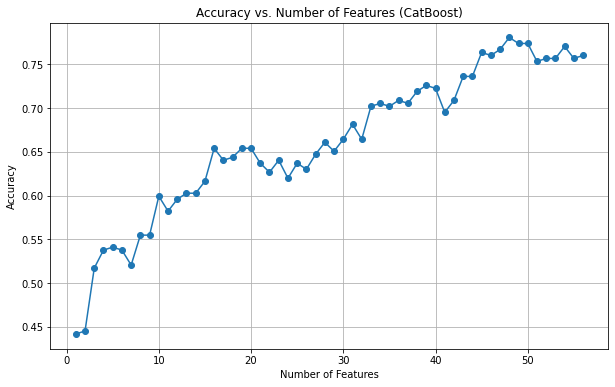

Top 48 features that yielded the best accuracy:
['q210c', 'q212a', 'q205d', 'q140b', 'q60c', 'q205c', 'q70c', 'q90a', 'q70a', 'q70e', 'q450e', 'q200a', 'demo_rank', 'q215l', 'q185i', 'demo_inst_carnegie_class', 'q215a', 'q70d', 'q45a', 'q70f', 'q195a', 'q105a', 'q90d', 'q70b', 'q60d', 'demo_race', 'q185k', 'q140a', 'q460a', 'q195e', 'q185h', 'q45b', 'q460b', 'q205a', 'q90c', 'q45c', 'q215c', 'q90h', 'q90g', 'q45e', 'q185l', 'q95a', 'q215i', 'q215d', 'q70h', 'q60e', 'q105e', 'q105d']


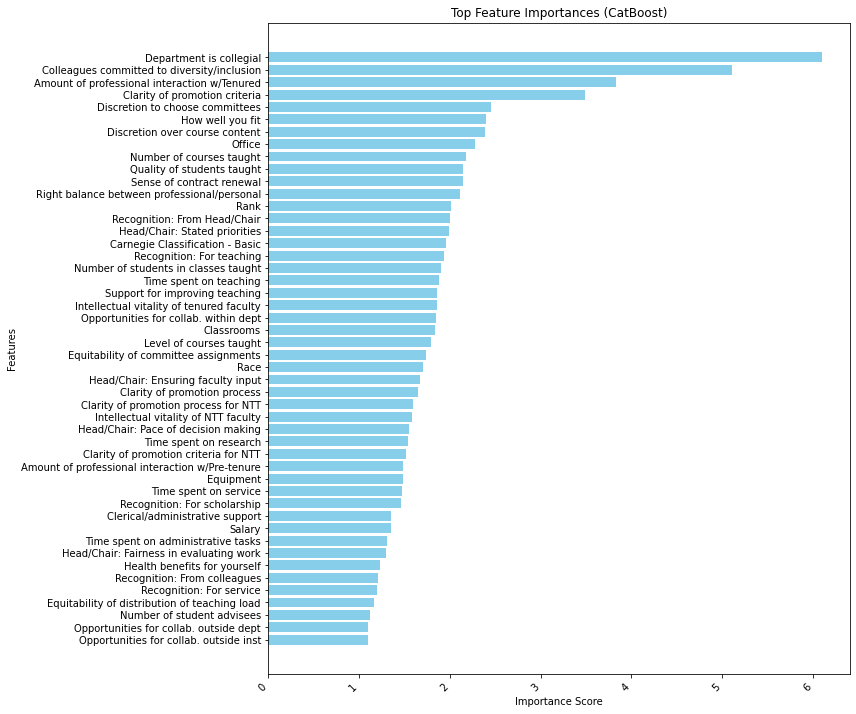

In [27]:
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV, train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

variables = [
    "q45a", "q45b", "q45c", "q45d", "q45e", "q45f",
    "q50a", "q50b", "q50c", "q50d", "q50e", "q50f",
    "q55a", "q55b", "q60a", "q60b", "q60c", "q60d",
    "q60f", "q60g", "q60e", "q60h", "q60i", "q70a",
    "q70b", "q70c", "q70d", "q70e", "q70i", "q70f",
    "q70h", "q70j", "q70k", "q70l", "q70m", "q70n",
    "q80a", "q80b", "q80c", "q80d", "q80e", "q85a",
    "q85b", "q85c", "q85d", "q85e", "q90a", "q90b",
    "q90c", "q90d", "q90e", "q90f", "q90g", "q90h",
    "q92a", "q92b", "q92c", "q92d", "q92e", "q92f",
    "q92g", "q92h", "q92i", "q92j", "q95a", "q95b",
    "q95c", "q95d", "q95e", "q95f", "q95g", "q95h",
    "q95i", "q95j", "q95k", "q95l", "q95m", "q95n",
    "q99", "q98a", "q98b", "q98c", "q100a", "q100b",
    "q100c", "q100d", "q100e", "q100f", "q100g", "q105a",
    "q105e", "q105d", "q115", "q120a", "q120b", "q120c",
    "q125a", "q125b", "q125c", "q130a", "q130b", "q130d",
    "q130c", "q135b", "q135c", "q135d", "q135e", "q136a",
    "q136b", "q136c", "q136d", "q136f", "q136e", "q132",
    "q133ns", "q137a", "q137b", "q137c", "q137d", "q137e",
    "q137f", "q137g", "q138a", "q138b", "q138c", "q138d",
    "q138e", "q138f", "q139a", "q139b", "q140a", "q140b",
    "q140c", "q140d", "q140e", "q140f", "q145a", "q145b",
    "q150", "q156a", "q156b", "q156c", "q156d", "q156e",
    "q156f", "q450a", "q450b", "q450c", "q450d", "q450e",
    "q460a", "q460b", "q460c", "q460d", "q460e", "q170a",
    "q170c", "q171", "q175a", "q175b", "q175c", "q180a",
    "q180b", "q180c", "q180l", "q180m", "q180n", "q180o",
    "q185d", "q185e", "q185f", "q185g", "q185h", "q185i",
    "q185j", "q185k", "q185l", "q187a", "q186a", "q186b",
    "q186c", "q186d", "q187b", "q188a", "q188b", "q188c",
    "q188d", "q188e", "q189a_a", "q189a_b", "q189a_c", "q189a_d",
    "q189a_e", "q189a_f", "q189b_a", "q189b_b", "q189b_c", "q189b_d",
    "q189b_e", "q189b_f", "q189b_g", "q190a", "q190b", "q190c",
    "q190d", "q190e", "q190f", "q190g", "q195a", "q195b",
    "q195e", "q195c", "q195d", "q195f", "q195g", "q195h",
    "q195i", "q200a", "q200b", "q200c", "q200d", "q205a",
    "q205b", "q205c", "q205d", "q205e", "q205f", "q205g",
    "q206a", "q206b", "q210a", "q210c", "q212a", "q212b",
    "q215a", "q215b", "q215c", "q215d", "q215e", "q215m",
    "q215j", "q215k", "q215l", "q215i", "q220a", "q220b", 
    "demo_rank","demo_race","demo_gender", "demo_inst_carnegie_class", 'q315'
]

# Prepare data
feature_names = variables  
X = instructional_data[feature_names]
y = instructional_data['q265']


# Step 1: Filter features with less than `tolerance` missing data
tolerance = 5
missing_data_percentage = X.isnull().mean() * 100
selected_features = missing_data_percentage[missing_data_percentage < tolerance].index.tolist()
X = X[selected_features]
print(f"Features with less than {tolerance}% missing data: {selected_features}")

# Step 2: Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Remove rows where y is NaN
valid_indices = ~y.isnull()
X_imputed = X_imputed[valid_indices]
y_cleaned = y[valid_indices]

# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_cleaned, test_size=0.3, random_state=42)

# Train CatBoost model
cat_model = CatBoostClassifier(auto_class_weights='Balanced', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=False)
cat_model.fit(X_train, y_train)

# Feature importance extraction
feature_importances = cat_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,  # Use original column names
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

# Feature selection and evaluation
features_sorted = importance_df["Feature"].tolist()
accuracy_scores = []
best_accuracy = 0
best_feature_count = 0

for i in range(1, len(features_sorted) + 1):
    selected_features = features_sorted[:i]
    X_train_selected = X_train[:, :i]  # Use only the top `i` features
    X_test_selected = X_test[:, :i]
    
    cat_model = CatBoostClassifier(auto_class_weights='Balanced', iterations=1000, learning_rate=0.1, depth=6, random_seed=42, verbose=False)
    cat_model.fit(X_train_selected, y_train)
    y_pred = cat_model.predict(X_test_selected)
    
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature_count = i

print(f"Best Accuracy: {best_accuracy:.2f} achieved with {best_feature_count} features.")

# Plot accuracy vs. number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(features_sorted) + 1), accuracy_scores, marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of Features (CatBoost)")
plt.grid(True)
plt.show()

# Map feature names to descriptions
df_mapping = pd.read_excel("Variables.xlsx")
df_mapping['key'] = df_mapping['key'].str.lower()
name_dict = dict(zip(df_mapping['key'], df_mapping['name']))

# Swap feature names with their mapped descriptions
importance_df["Feature"] = [
    name_dict.get(feat.lower(), feat) for feat in importance_df["Feature"]
]

# Plot top feature importances
top_n = best_feature_count
top_features = importance_df.head(top_n)
best_features = features_sorted[:best_feature_count]
print(f"Top {best_feature_count} features that yielded the best accuracy:")
print(best_features)

plt.figure(figsize=(12, 10))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.title("Top Feature Importances (CatBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()


In [23]:
best_features = features_sorted[:best_feature_count]
print(f"Top {best_feature_count} features that yielded the best accuracy:")
print(best_features)

Top 48 features that yielded the best accuracy:
['q210c', 'q212a', 'q205d', 'q140b', 'q60c', 'q205c', 'q70c', 'q90a', 'q70a', 'q70e', 'q450e', 'q200a', 'demo_rank', 'q215l', 'q185i', 'demo_inst_carnegie_class', 'q215a', 'q70d', 'q45a', 'q70f', 'q195a', 'q105a', 'q90d', 'q70b', 'q60d', 'demo_race', 'q185k', 'q140a', 'q460a', 'q195e', 'q185h', 'q45b', 'q460b', 'q205a', 'q90c', 'q45c', 'q215c', 'q90h', 'q90g', 'q45e', 'q185l', 'q95a', 'q215i', 'q215d', 'q70h', 'q60e', 'q105e', 'q105d']


In [20]:
from sklearn.metrics import classification_report

# After fitting the final model and making predictions
y_pred = cat_model.predict(X_test_selected)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.59      0.67        27
         1.0       0.75      0.67      0.71       124
         2.0       0.77      0.87      0.82       141

    accuracy                           0.76       292
   macro avg       0.76      0.71      0.73       292
weighted avg       0.76      0.76      0.76       292



Let's explore a cluster analysis on the 48 featuers

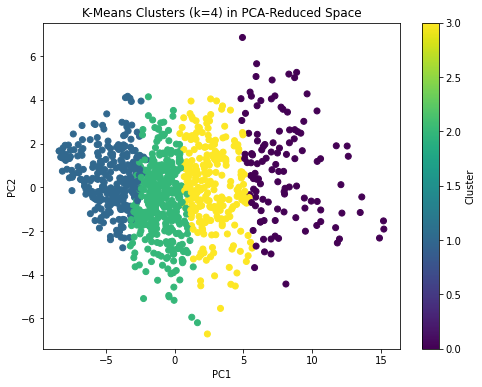

            q210c     q212a     q205d     q140b      q60c     q205c      q70c  \
Cluster                                                                         
0        2.153846  2.282051  2.350427  1.726496  2.358974  1.905983  2.931624   
1        4.642308  4.700000  4.353846  4.434615  4.323077  4.538462  4.696154   
2        4.322767  4.345821  3.913545  4.204611  3.792507  4.060519  4.155620   
3        3.587045  3.663968  3.210526  3.242915  3.036437  3.194332  3.704453   

             q90a      q70a      q70e  ...      q90g      q45e     q185l  \
Cluster                                ...                                 
0        2.649573  2.666667  2.512821  ...  2.051282  2.512821  1.923077   
1        4.315385  4.450000  4.065385  ...  3.734615  4.111538  4.646154   
2        3.625360  3.703170  3.233429  ...  2.864553  3.314121  4.256484   
3        3.356275  3.271255  2.838057  ...  2.497976  2.971660  3.275304   

             q95a     q215i     q215d      q70h      q60

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Create final_feature_list
final_feature_list = features_sorted[:best_feature_count]

# 2. Subset the already-imputed DataFrame X
X_clustering = X[final_feature_list].copy()  # X is already imputed


# 4. If needed, re-impute or fill
imputer = SimpleImputer(strategy="most_frequent")
X_clustering_imputed = imputer.fit_transform(X_clustering)
X_clustering = pd.DataFrame(X_clustering_imputed, columns=X_clustering.columns)

# 5. Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 6. KMeans
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

# 7. Attach cluster labels for analysis
X_clustering['Cluster'] = cluster_labels

# 8. PCA plot
pca = PCA(n_components=2)
pc = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pc[:, 0], pc[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clusters (k={k_optimal}) in PCA-Reduced Space')
plt.colorbar(label='Cluster')
plt.show()

# 9. Summarize by cluster
print(X_clustering.groupby('Cluster').mean())
